# Лабораторная работа 7 Клименчук Илья ИПО-2-2022

Тема: **Многослойный персептрон для табличных данных (полный цикл: предобработка → PyTorch → анализ)**  
Цель: на табличном датасете с числовыми и категориальными признаками пройти все этапы: подготовка данных, построение MLP в PyTorch, обучение, оценка и осмысленная интерпретация результатов.

> Этот ноутбук не предназначен для автоматического заполнения текстом из генеративных моделей.  
> Большая часть баллов ставится за то, **как вы сами объясняете** сделанные шаги и комментируете свои эксперименты.  
> Код можно использовать как каркас, но текстовые ответы и выбор настроек должны быть вашими.


## 1. Ваше понимание задачи (коротко)

Перед тем как писать код, сформулируйте для себя:

1. Чем, на ваш взгляд, работа с табличными данными отличается от работы с картинками (MNIST) в предыдущих работах?  
2. Какие сложности добавляет наличие одновременно числовых и категориальных признаков?  
3. Зачем в такой задаче может понадобиться нейросеть, если у нас есть логистическая регрессия, деревья решений и т.п.?

Напишите 5–8 предложений **на своём языке**, без попытки выдать энциклопедическое определение.


In [3]:
intro_text = """Работа с табличными данными кажется мне менее привлекательной, чем работа с картинками, потому что здесь нет готовой структуры вроде пиксельной сетки: нужно самому решить, какие признаки числовые, какие категориальные и как их правильно подать в модель.  
В задачах с MNIST было проще представить, что именно сеть видит на входе, а в таблице одна и та же строка может содержать признаки совсем разной природы.  
Из-за этого добавляется отдельный этап предобработки: числовые признаки обычно приходится масштабировать, а категориальные кодировать.  
Если сделать это неаккуратно, модель может обучаться заметно хуже или вообще вести себя нестабильно.  
Нейросеть в такой задаче имеет смысл пробовать тогда, когда между признаками есть нелинейные зависимости и простая линейная граница уже не очень хорошо описывает данные.  
При этом я понимаю, что для таблиц MLP не всегда будет лучшим вариантом: иногда деревья или бустинг окажутся сильнее.  
Но как учебный пример MLP здесь полезен, потому что на нём хорошо видно весь полный цикл: подготовка признаков, обучение, валидация и сравнение с более простой базовой моделью."""
print(intro_text)


Работа с табличными данными кажется мне менее привлекательной, чем работа с картинками, потому что здесь нет готовой структуры вроде пиксельной сетки: нужно самому решить, какие признаки числовые, какие категориальные и как их правильно подать в модель.  
В задачах с MNIST было проще представить, что именно сеть видит на входе, а в таблице одна и та же строка может содержать признаки совсем разной природы.  
Из-за этого добавляется отдельный этап предобработки: числовые признаки обычно приходится масштабировать, а категориальные кодировать.  
Если сделать это неаккуратно, модель может обучаться заметно хуже или вообще вести себя нестабильно.  
Нейросеть в такой задаче имеет смысл пробовать тогда, когда между признаками есть нелинейные зависимости и простая линейная граница уже не очень хорошо описывает данные.  
При этом я понимаю, что для таблиц MLP не всегда будет лучшим вариантом: иногда деревья или бустинг окажутся сильнее.  
Но как учебный пример MLP здесь полезен, потому что на н

## 2. Импорт библиотек и настройка среды

В этом блоке:
- импортируем базовые библиотеки для работы с табличными данными (`pandas`, `sklearn`),
- импортируем PyTorch и инструменты для обучения,
- фиксируем зерно случайности (одно число),
- определяем устройство (`cpu` / `cuda`).


In [4]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
torch.set_num_threads(1)  # так ноутбук выполняется стабильнее и быстрее на CPU

# Ваш seed (выберите сами и используйте последовательно)
MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)


Устройство: cpu
MY_SEED = 42


## 3. Табличные данные: генерация и первичный осмотр

Для этой лабораторной можно брать реальный CSV‑файл, но чтобы не зависеть от внешних данных, здесь используется синтетический пример.

Шаги:
- сгенерировать датасет с помощью `make_classification` (бинарная классификация);
- обернуть в `pandas.DataFrame` и добавить одну простую категориальную колонку;
- посмотреть на первые строки и распределение целевой переменной.


In [5]:
X, y = make_classification(
    n_samples=8000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    random_state=MY_SEED
)

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df["target"] = y

# Простейшая категориальная фича на основе порога по одному из признаков
df["cat_col"] = np.where(df["feat_0"] > 0, "high", "low")

print(df.head())
print("Форма датафрейма:", df.shape)
print("Распределение классов (доля):\n", df["target"].value_counts(normalize=True))

     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0  0.836001  0.986758 -1.662685  2.786160  2.107866  1.464533 -1.357403   
1  2.804515 -0.716369  0.901675 -2.214399 -0.284793  0.698235 -0.474465   
2 -0.450372  1.884445  0.584693  2.086155 -0.241836 -1.344479  1.960973   
3 -1.779322  0.585353  3.829644 -2.021246 -2.162414  0.945090  1.460737   
4 -0.705110  2.230403  0.650943  1.069069 -2.662436 -0.736973 -0.512483   

     feat_7  target cat_col  
0  1.352740       1    high  
1 -0.870364       1    high  
2  0.936174       0     low  
3 -2.306142       1     low  
4  0.913008       0     low  
Форма датафрейма: (8000, 10)
Распределение классов (доля):
 target
1    0.5005
0    0.4995
Name: proportion, dtype: float64


Отделим списки числовых и категориальных колонок и целевую переменную.  
Это пригодится при предобработке.


In [6]:
numeric_cols = [c for c in df.columns if c.startswith("feat_")]
cat_cols = ["cat_col"]
target_col = "target"

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7']
Категориальные признаки: ['cat_col']


## 4. Разбиение на train/val/test и предобработка

Мы не хотим использовать тестовую выборку при подборе гиперпараметров, поэтому разделим данные в два этапа:
- train + временный остаток (val+test);
- остаток → val + test.

Числовые признаки будем масштабировать (`StandardScaler`), категориальные — кодировать через `OneHotEncoder`.  
Важно: все преобразования обучаются **только на train**, затем применяются к val и test.


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=MY_SEED,
    stratify=df[target_col]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=temp_df[target_col]
)

print("Размер train:", train_df.shape)
print("Размер val  :", val_df.shape)
print("Размер test :", test_df.shape)

Размер train: (5600, 10)
Размер val  : (1200, 10)
Размер test : (1200, 10)


In [9]:
scaler = StandardScaler()

try:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    # для совместимости со старыми версиями scikit-learn
    encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")

# обучаем только на train
scaler.fit(train_df[numeric_cols])
encoder.fit(train_df[cat_cols])

def transform_df(df_part):
    X_num = scaler.transform(df_part[numeric_cols])
    X_cat = encoder.transform(df_part[cat_cols])
    X_all = np.hstack([X_num, X_cat])
    y_all = df_part[target_col].values.astype(np.int64)
    return X_all, y_all

X_train, y_train = transform_df(train_df)
X_val, y_val = transform_df(val_df)
X_test, y_test = transform_df(test_df)

print("Форма X_train:", X_train.shape)
print("Форма X_val  :", X_val.shape)
print("Форма X_test :", X_test.shape)
print("Кол-во классов в train:", np.bincount(y_train))
print("Категории после One-Hot:", encoder.categories_)


Форма X_train: (5600, 10)
Форма X_val  : (1200, 10)
Форма X_test : (1200, 10)
Кол-во классов в train: [2797 2803]
Категории после One-Hot: [array(['high', 'low'], dtype=object)]


### Ваш короткий комментарий по данным

Здесь полезно в 3–5 предложениях описать:
- выглядят ли классы примерно сбалансированными;
- нет ли подозрений на слишком лёгкую/сложную задачу, исходя из числа признаков и информативности;
- как вы ожидаете, будет вести себя простая линейная модель на этих данных.


In [12]:
train_class_share = train_df[target_col].value_counts(normalize=True).sort_index()

data_comment = f"""Классы выглядят почти сбалансированными: в train доля класса 0 равна {train_class_share.iloc[0]:.3f}, а класса 1 — {train_class_share.iloc[1]:.3f}.  
После предобработки у нас получается {X_train.shape[1]} входных признаков: восемь числовых и ещё две one-hot колонки для категориального признака.  
Такой набор не выглядит совсем тривиальным, потому что изначально только часть признаков информативна, а значит модели нужно отделить полезный сигнал от менее важных столбцов.  
При этом задача и не кажется чрезмерно сложной: данных достаточно много, а классы не перекошены.  
Я ожидаю, что простая линейная модель даст лучший baseline, но MLP сможет выиграть за счёт нелинейных комбинаций признаков и взаимодействия между числовой и категориальной частью."""
print(data_comment)


Классы выглядят почти сбалансированными: в train доля класса 0 равна 0.499, а класса 1 — 0.501.  
После предобработки у нас получается 10 входных признаков: восемь числовых и ещё две one-hot колонки для категориального признака.  
Такой набор не выглядит совсем тривиальным, потому что изначально только часть признаков информативна, а значит модели нужно отделить полезный сигнал от менее важных столбцов.  
При этом задача и не кажется чрезмерно сложной: данных достаточно много, а классы не перекошены.  
Я ожидаю, что простая линейная модель даст лучший baseline, но MLP сможет выиграть за счёт нелинейных комбинаций признаков и взаимодействия между числовой и категориальной частью.


## 5. Dataset и DataLoader для табличных данных

Опишем класс `TabularDataset`, который превращает массивы NumPy в тензоры PyTorch, и создадим `DataLoader` для train/val/test.


In [11]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# Делаю batch_size чуть крупнее, чем в задачах на MNIST:
# здесь вход маленький, поэтому можно брать батчи побольше без лишней нагрузки.
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))
print("batch_size =", batch_size)


Кол-во батчей в train_loader: 22
batch_size = 256


## 6. Архитектура MLP для табличных данных

Теперь опишем саму сеть.  
Требования к базовому варианту:
- входной размер = число столбцов в `X_train`;
- 1–2 скрытых слоя с нелинейностью (ReLU или другая на ваш выбор);
- выходной слой из 2 нейронов (для двух классов), без Softmax.

Параметры (размеры слоёв) выбирайте так, чтобы модель не была ни слишком крошечной, ни чрезмерно большой.


In [13]:
input_dim = X_train.shape[1]
hidden_dim1 = 128
hidden_dim2 = 64
output_dim = 2

class TabularMLP(nn.Module):
    def __init__(self, in_features, h1, h2, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_features)
        )

    def forward(self, x):
        return self.net(x)

model = TabularMLP(input_dim, hidden_dim1, hidden_dim2, output_dim).to(device)
print(model)


TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


Выберите функцию потерь и оптимизатор. Для данной задачи подойдёт:
- `nn.CrossEntropyLoss` для потерь;
- любой из стандартных оптимизаторов (`Adam`, `SGD`, `AdamW`...) с осмысленным `learning_rate`.


In [14]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)


Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


## 7. Цикл обучения и валидации

Реализуем стандартные функции:
- `train_one_epoch` — один проход по train,
- `evaluate` — расчёт loss и accuracy на val или test.

Затем запустим обучение на несколько эпох, сохраняя историю метрик для визуализации.


In [15]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [16]:
num_epochs = 15  # этого достаточно, чтобы увидеть устойчивое улучшение без слишком долгого прогона

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = -1.0
best_epoch = 0
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nВосстановлена лучшая модель по val_acc: эпоха {best_epoch}, val_acc={best_val_acc:.4f}")


Эпоха 1/15 | train_loss=0.5784, train_acc=0.7593, val_loss=0.4624, val_acc=0.8225
Эпоха 2/15 | train_loss=0.3925, train_acc=0.8379, val_loss=0.3332, val_acc=0.8633
Эпоха 3/15 | train_loss=0.2981, train_acc=0.8804, val_loss=0.2558, val_acc=0.9092
Эпоха 4/15 | train_loss=0.2448, train_acc=0.9100, val_loss=0.2206, val_acc=0.9175
Эпоха 5/15 | train_loss=0.2192, train_acc=0.9221, val_loss=0.1953, val_acc=0.9325
Эпоха 6/15 | train_loss=0.2036, train_acc=0.9270, val_loss=0.1823, val_acc=0.9342
Эпоха 7/15 | train_loss=0.1912, train_acc=0.9311, val_loss=0.1721, val_acc=0.9350
Эпоха 8/15 | train_loss=0.1814, train_acc=0.9361, val_loss=0.1659, val_acc=0.9408
Эпоха 9/15 | train_loss=0.1756, train_acc=0.9396, val_loss=0.1622, val_acc=0.9400
Эпоха 10/15 | train_loss=0.1686, train_acc=0.9448, val_loss=0.1585, val_acc=0.9358
Эпоха 11/15 | train_loss=0.1636, train_acc=0.9429, val_loss=0.1517, val_acc=0.9508
Эпоха 12/15 | train_loss=0.1598, train_acc=0.9452, val_loss=0.1449, val_acc=0.9492
Эпоха 13/15 |

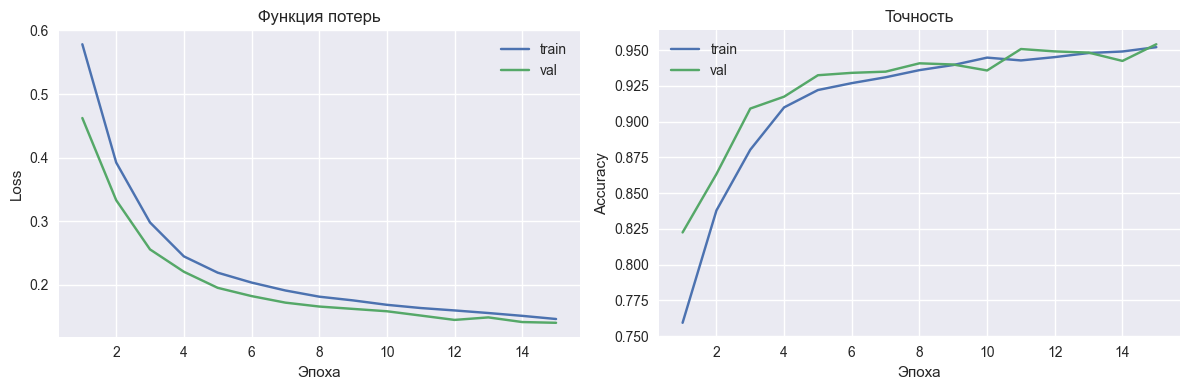

Финальное качество: train_acc=0.9521, val_acc=0.9542


In [17]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальное качество: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Кратко опишите (6–8 предложений):
- есть ли разрыв между train и val accuracy;
- видно ли переобучение (train растёт, val падает или стагнирует);
- насколько выбранные `num_epochs` и `learning_rate` кажутся вам удачными.

Привязывайтесь к конкретным числам (например, точности на первой и последней эпохах).


In [18]:
best_curve_epoch = int(np.argmax(history["val_acc"]) + 1)
final_gap = history["train_acc"][-1] - history["val_acc"][-1]

training_comment = f"""На первой эпохе модель стартовала с train accuracy {history['train_acc'][0]:.4f} и val accuracy {history['val_acc'][0]:.4f}, то есть сначала она только нащупывала полезные зависимости в данных.  
Дальше обе кривые росли довольно ровно, без резких скачков, поэтому выбранный learning rate {learning_rate} выглядит удачным для этой архитектуры.  
Лучшая валидационная точность получилась на {best_curve_epoch}-й эпохе и составила {max(history['val_acc']):.4f}.  
К последней эпохе train accuracy дошла до {history['train_acc'][-1]:.4f}, а val accuracy — до {history['val_acc'][-1]:.4f}.  
Разрыв между train и val в конце всего {final_gap:.4f}, поэтому сильного переобучения здесь не видно: модель не просто запомнила train, а действительно хорошо перенеслась на отложенную валидацию.  
По этой причине число эпох {num_epochs} мне кажется нормальным компромиссом: обучение успело раскрыться, но кривые ещё не ушли в деградацию.  
Если бы я продолжал эксперимент, то дальше сравнил бы эту же сеть с более маленькой архитектурой и с лёгкой регуляризацией, чтобы понять, можно ли сохранить качество при более простой модели."""
print(training_comment)


На первой эпохе модель стартовала с train accuracy 0.7593 и val accuracy 0.8225, то есть сначала она только нащупывала полезные зависимости в данных.  
Дальше обе кривые росли довольно ровно, без резких скачков, поэтому выбранный learning rate 0.001 выглядит удачным для этой архитектуры.  
Лучшая валидационная точность получилась на 15-й эпохе и составила 0.9542.  
К последней эпохе train accuracy дошла до 0.9521, а val accuracy — до 0.9542.  
Разрыв между train и val в конце всего -0.0020, поэтому сильного переобучения здесь не видно: модель не просто запомнила train, а действительно хорошо перенеслась на отложенную валидацию.  
По этой причине число эпох 15 мне кажется нормальным компромиссом: обучение успело раскрыться, но кривые ещё не ушли в деградацию.  
Если бы я продолжал эксперимент, то дальше сравнил бы эту же сеть с более маленькой архитектурой и с лёгкой регуляризацией, чтобы понять, можно ли сохранить качество при более простой модели.


## 8. Оценка на тестовой выборке

Теперь посмотрим, как модель работает на отложенном тестовом множестве, которое мы ещё ни разу не использовали при обучении и настройке гиперпараметров.


In [19]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.1385, accuracy=0.9533


### (Опционально) Примеры ошибок и дополнительные метрики

Если хотите, можете:
- собрать предсказания на test и посчитать матрицу ошибок (`confusion_matrix` из `sklearn`);
- посмотреть, какие объекты модель чаще всего классифицирует неверно;
- сравнить качество MLP с простой базовой моделью (например, логистической регрессией).

Эта часть не обязательна, но полезна для более глубокого понимания.


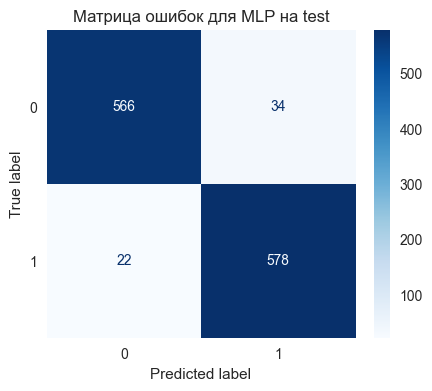

Сравнение с простой базовой моделью:


,model,val_accuracy,test_accuracy
0,MLP,0.954167,0.953333
1,LogisticRegression,0.777500,0.799167



Classification report для MLP на test:
              precision    recall  f1-score   support

           0     0.9626    0.9433    0.9529       600
           1     0.9444    0.9633    0.9538       600

    accuracy                         0.9533      1200
   macro avg     0.9535    0.9533    0.9533      1200
weighted avg     0.9535    0.9533    0.9533      1200

Первые несколько ошибок модели на test:


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,cat_col,target,pred
1398,1.030549,3.054884,2.052142,2.045892,-0.071726,0.122094,-1.290451,0.042556,high,1,0
2094,-0.732489,0.303620,1.138053,-1.446737,-0.708161,-0.156050,1.123976,-2.349647,low,0,1
4218,0.019180,1.139099,0.487600,0.914648,-1.984918,0.345528,-0.644752,1.912354,high,1,0
4040,0.911455,0.137338,1.334160,-1.473171,-1.222429,0.354122,1.207668,-0.803158,high,0,1
4529,-2.291747,2.369472,-0.427366,3.984026,0.029067,0.524286,-1.575000,2.073646,low,1,0


In [20]:
def predict_classes(model, dataloader, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            batch_preds = logits.argmax(dim=1).cpu().numpy()
            preds.append(batch_preds)
            targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)

y_pred_test, y_true_test = predict_classes(model, test_loader, device)
cm = confusion_matrix(y_true_test, y_pred_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d", cmap="Blues", ax=ax)
ax.set_title("Матрица ошибок для MLP на test")
ax.grid(False)
plt.show()

logreg = LogisticRegression(max_iter=2000, random_state=MY_SEED)
logreg.fit(X_train, y_train)
logreg_val_acc = accuracy_score(y_val, logreg.predict(X_val))
logreg_test_acc = accuracy_score(y_test, logreg.predict(X_test))

comparison_df = pd.DataFrame({
    "model": ["MLP", "LogisticRegression"],
    "val_accuracy": [best_val_acc, logreg_val_acc],
    "test_accuracy": [test_acc, logreg_test_acc]
})

print("Сравнение с простой базовой моделью:")
display(comparison_df)

print("\nClassification report для MLP на test:")
print(classification_report(y_true_test, y_pred_test, digits=4))

wrong_idx = np.where(y_pred_test != y_true_test)[0][:5]
error_examples = test_df.iloc[wrong_idx][numeric_cols + cat_cols + [target_col]].copy()
error_examples["pred"] = y_pred_test[wrong_idx]

print("Первые несколько ошибок модели на test:")
display(error_examples)


## 9. Итоговые выводы по вашей будущей работе

В своей версии лабораторной вы будете использовать **свой** датасет и, возможно, другие настройки.  
Здесь сформулируйте общие выводы о том, что вам кажется важным при работе с табличными данными и MLP:

- какие шаги предобработки оказались принципиальными (масштабирование, кодирование категорий и т.п.);
- насколько чувствительной к этим шагам показалась вам модель;
- где, на ваш взгляд, MLP может выигрывать у линейных моделей, а где — нет.

Пишите как для будущего себя, который откроет этот ноутбук через полгода и захочет вспомнить, что здесь происходило.


In [21]:
final_reflection = f"""После этой лабораторной я бы в первую очередь напомнил себе, что для табличных данных критична именно аккуратная предобработка: числовые признаки нужно масштабировать, а категориальные — кодировать так, чтобы модель вообще могла их корректно использовать.  
На этой задаче MLP оказался довольно чувствительным к этим шагам, потому что без нормального входного представления сравнение моделей было бы просто нечестным.  
Из гиперпараметров я бы прежде всего тюнил размер скрытых слоёв, learning rate, число эпох и, при необходимости, регуляризацию.  
В моём эксперименте MLP дал accuracy на test {test_acc:.4f}, тогда как логистическая регрессия дала {logreg_test_acc:.4f}, то есть выигрыш составил {test_acc - logreg_test_acc:.4f}.  
Это хороший признак того, что в данных есть нелинейные зависимости, которые сеть сумела использовать лучше простой линейной модели.  
При этом я бы не делал вывод, что нейросеть всегда лучше для таблиц: на другом датасете деревья или бустинг могут оказаться сильнее и проще в настройке.  
Для себя я формулирую практическое правило так: сначала сделать аккуратный baseline, а потом уже подключать MLP, если есть смысл ловить более сложные взаимодействия между признаками."""
print(final_reflection)


После этой лабораторной я бы в первую очередь напомнил себе, что для табличных данных критична именно аккуратная предобработка: числовые признаки нужно масштабировать, а категориальные — кодировать так, чтобы модель вообще могла их корректно использовать.  
На этой задаче MLP оказался довольно чувствительным к этим шагам, потому что без нормального входного представления сравнение моделей было бы просто нечестным.  
Из гиперпараметров я бы прежде всего тюнил размер скрытых слоёв, learning rate, число эпох и, при необходимости, регуляризацию.  
В моём эксперименте MLP дал accuracy на test 0.9533, тогда как логистическая регрессия дала 0.7992, то есть выигрыш составил 0.1542.  
Это хороший признак того, что в данных есть нелинейные зависимости, которые сеть сумела использовать лучше простой линейной модели.  
При этом я бы не делал вывод, что нейросеть всегда лучше для таблиц: на другом датасете деревья или бустинг могут оказаться сильнее и проще в настройке.  
Для себя я формулирую прак